# SETUP

<div style="padding:10px;
            color:#E55604;
            margin:10px;
            font-size:130%;
            display:fill;
            border-radius:5px;
            border-style: solid;
            border-color: #FF9B50;
            background-color:#000000;
            overflow:hidden;
            font-weight:400"><b>Importing Libraries</b>
</div>

In [15]:
! pip install ucimlrepo



[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo 
import warnings
warnings.filterwarnings("ignore")

colors = ["#89CFF0", "#FF69B4", "#FFD700", "#7B68EE", "#FF4500",
          "#9370DB", "#32CD32", "#8A2BE2", "#FF6347", "#20B2AA",
          "#FF69B4", "#00CED1", "#FF7F50", "#7FFF00", "#DA70D6"]

palette = sns.color_palette(colors)
sns.set_palette(palette)
sns.set_style("whitegrid")
sns.set_context("notebook")

pd.options.display.float_format = '{:,.2f}'.format
pd.set_option('display.max_columns', 100)
plt.rcParams['figure.figsize'] = (10, 5)
palette
  
# fetch dataset 
heart_disease = fetch_ucirepo(id=45) 
  
# data (as pandas dataframes) 
X = heart_disease.data.features 
y = heart_disease.data.targets 
  
# metadata 
print(heart_disease.metadata) 
  
# variable information 
print(heart_disease.variables) 


{'uci_id': 45, 'name': 'Heart Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/45/heart+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/45/data.csv', 'abstract': '4 databases: Cleveland, Hungary, Switzerland, and the VA Long Beach', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 303, 'num_features': 13, 'feature_types': ['Categorical', 'Integer', 'Real'], 'demographics': ['Age', 'Sex'], 'target_col': ['num'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1989, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C52P4X', 'creators': ['Andras Janosi', 'William Steinbrunn', 'Matthias Pfisterer', 'Robert Detrano'], 'intro_paper': {'ID': 231, 'type': 'NATIVE', 'title': 'International application of a new probability algorithm for the diagnosis of coronary artery disease.', 'authors': 'R. Detrano, A. Jánosi, W. Steinbrunn, M

# LOADING DATASET

<div style="padding:10px;
            color:#E55604;
            margin:10px;
            font-size:130%;
            display:fill;
            border-radius:5px;
            border-style: solid;
            border-color: #FF9B50;
            background-color:#000000;
            overflow:hidden;
            font-weight:400"><b>Import dataset using Pandas</b>
</div>

In [17]:
url = "../data/heart_disease.csv"

df = pd.read_csv(url)

print(df.head())


   63.0  1.0  1.0.1  145.0  233.0  1.0.2  2.0  150.0  0.0  2.3  3.0 0.0.1  \
0 67.00 1.00   4.00 160.00 286.00   0.00 2.00 108.00 1.00 1.50 2.00   3.0   
1 67.00 1.00   4.00 120.00 229.00   0.00 2.00 129.00 1.00 2.60 2.00   2.0   
2 37.00 1.00   3.00 130.00 250.00   0.00 0.00 187.00 0.00 3.50 3.00   0.0   
3 41.00 0.00   2.00 130.00 204.00   0.00 2.00 172.00 0.00 1.40 1.00   0.0   
4 56.00 1.00   2.00 120.00 236.00   0.00 0.00 178.00 0.00 0.80 1.00   0.0   

   6.0  0  
0  3.0  2  
1  7.0  1  
2  3.0  0  
3  3.0  0  
4  3.0  0  


# Add Columns Names

In [18]:
columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", 
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

df.columns = columns
print(df.head())


    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0 67.00 1.00 4.00    160.00 286.00 0.00     2.00   108.00   1.00     1.50   
1 67.00 1.00 4.00    120.00 229.00 0.00     2.00   129.00   1.00     2.60   
2 37.00 1.00 3.00    130.00 250.00 0.00     0.00   187.00   0.00     3.50   
3 41.00 0.00 2.00    130.00 204.00 0.00     2.00   172.00   0.00     1.40   
4 56.00 1.00 2.00    120.00 236.00 0.00     0.00   178.00   0.00     0.80   

   slope   ca thal  target  
0   2.00  3.0  3.0       2  
1   2.00  2.0  7.0       1  
2   3.00  0.0  3.0       0  
3   1.00  0.0  3.0       0  
4   1.00  0.0  3.0       0  


# DATA INSPECTION

<div style="padding:10px;
            color:#E55604;
            margin:10px;
            font-size:130%;
            display:fill;
            border-radius:5px;
            border-style: solid;
            border-color: #FF9B50;
            background-color:#000000;
            overflow:hidden;
            font-weight:400"><b>Checking the shape of the Dataset</b>
</div>

In [19]:
df.shape

(302, 14)

<div style="padding:10px;
            color:#E55604;
            margin:10px;
            font-size:130%;
            display:fill;
            border-radius:5px;
            border-style: solid;
            border-color: #FF9B50;
            background-color:#000000;
            overflow:hidden;
            font-weight:400"><b>Checking the number of Columns in the Dataset</b>
</div>

In [20]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

<div style="padding:10px;
            color:#E55604;
            margin:10px;
            font-size:130%;
            display:fill;
            border-radius:5px;
            border-style: solid;
            border-color: #FF9B50;
            background-color:#000000;
            overflow:hidden;
            font-weight:400"><b>Information about the Dataset</b>
</div>

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    float64
 1   sex       302 non-null    float64
 2   cp        302 non-null    float64
 3   trestbps  302 non-null    float64
 4   chol      302 non-null    float64
 5   fbs       302 non-null    float64
 6   restecg   302 non-null    float64
 7   thalach   302 non-null    float64
 8   exang     302 non-null    float64
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    float64
 11  ca        302 non-null    object 
 12  thal      302 non-null    object 
 13  target    302 non-null    int64  
dtypes: float64(11), int64(1), object(2)
memory usage: 33.2+ KB


In [22]:
cat_features = df.select_dtypes(include='object').columns.values
num_features = df.select_dtypes(exclude='object').columns.values

print("Categorical Features: \n\n", cat_features)
print("\n","="*80)
print("Numerical Features: \n\n", num_features)

Categorical Features: 

 ['ca' 'thal']

Numerical Features: 

 ['age' 'sex' 'cp' 'trestbps' 'chol' 'fbs' 'restecg' 'thalach' 'exang'
 'oldpeak' 'slope' 'target']


In [23]:
df.describe(include='number')

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
count,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00,302.00
mean,54.41,0.68,3.17,131.65,246.74,0.15,0.99,149.61,0.33,1.04,1.60,0.94
std,9.04,0.47,0.95,17.61,51.86,0.35,0.99,22.91,0.47,1.16,0.61,1.23
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.25,0.00,0.00,1.00,0.00
50%,55.50,1.00,3.00,130.00,241.50,0.00,0.50,153.00,0.00,0.80,2.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,2.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,4.00


In [24]:
df.describe(exclude='number').T

,count,unique,top,freq
ca,302,5,0.0,175
thal,302,4,3.0,166


# DATA CLEANING

<div style="padding:10px;
            color:#E55604;
            margin:10px;
            font-size:130%;
            display:fill;
            border-radius:5px;
            border-style: solid;
            border-color: #FF9B50;
            background-color:#000000;
            overflow:hidden;
            font-weight:400"><b>Checking if there are any null values present in the dataset or not ?</b>
</div>

In [25]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

<div style="padding:10px;
            color:#E55604;
            margin:10px;
            font-size:130%;
            display:fill;
            border-radius:5px;
            border-style: solid;
            border-color: #FF9B50;
            background-color:#000000;
            overflow:hidden;
            font-weight:400"><b>Checking if there are any duplicate values present in the dataset or not ?</b>
</div>

In [26]:
df.duplicated().sum()

np.int64(0)

<div style="padding:10px;
            color:#E55604;
            margin:10px;
            font-size:130%;
            display:fill;
            border-radius:5px;
            border-style: solid;
            border-color: #FF9B50;
            background-color:#000000;
            overflow:hidden;
            font-weight:400"><b>Checking if there are zeros values the dataset?</b>
</div>

In [27]:
(df == 0).sum()


age           0
sex          97
cp            0
trestbps      0
chol          0
fbs         258
restecg     151
thalach       0
exang       203
oldpeak      99
slope         0
ca            0
thal          0
target      163
dtype: int64

# EDA FOR CATEGORICAL FEATURES

<div style="padding:10px;
            color:#E55604;
            margin:10px;
            font-size:130%;
            display:fill;
            border-radius:5px;
            border-style: solid;
            border-color: #FF9B50;
            background-color:#000000;
            overflow:hidden;
            font-weight:400"><b>Bar chart steps </b>
</div>

1. Prepare the data to visualize.
2. Set up the figure size.
3. Plot the bar chart for the column in the DataFrame
4. Annotate each bar with its height (number of occurrences)
5. Set the title and labels for the x and y axes

# Fixing labels for sex column

In [28]:
df["sex"] = df["sex"].map({1: "Male", 0: "Female"})

gender_counts = df["sex"].value_counts().reset_index()
gender_counts.columns = ["sex", "count"]

print(gender_counts)


      sex  count
0    Male    205
1  Female     97


In [29]:
# Step 2: Set up the figure size
plt.figure(figsize=(5,4))

# Step 3: Plot the bar chart for the 'Gender' column in the DataFrame 'df'
ax = sns.barplot(data = gender_counts, x='sex', y=' ', palette= palette)

# Step 4: Annotate each bar with its height (number of occurrences)
for p in ax.patches:
    x_coor = p.get_x() + 0.5 * p.get_width()
    y_coor = p.get_height()
    hight = int(p.get_height())

    ax.annotate(hight,            # Text to be displayed (converted to int for formatting)
                (x_coor, y_coor), # Coordinates of the annotation (x, y)
                ha='center',      # Horizontal alignment of the text ('center' aligns it at the center of the x-coordinate)
                va='bottom',      # Vertical alignment of the text ('bottom' aligns it at the bottom of the bar)
                color='black'     # Color of the text
                )
    
# Step 5: Set tick parameters and font size for both axes
ax.tick_params(axis = 'both', labelsize = 10)

# Step 6: Set the title and labels for the x and y axes
plt.title('Number of Patients per gender', weight = "bold", fontsize = 14, pad = 20)
plt.xlabel('Patients Gender', weight = "bold",  fontsize = 12, labelpad = 20)
plt.ylabel('Number of Patients', weight = "bold", fontsize = 12, labelpad = 20)
plt.tight_layout()
plt.show()


ValueError: Could not interpret value ` ` for `y`. An entry with this name does not appear in `data`.

<Figure size 500x400 with 0 Axes>

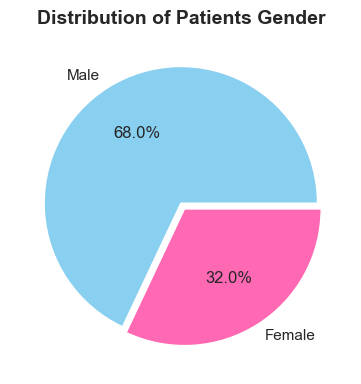

In [ ]:
plt.figure(figsize=(4,4))

explode = (0, 0.05)
ax = plt.pie(gender_counts['count'], 
             labels=gender_counts['sex'], 
             explode = explode, 
             autopct = '%1.1f%%')

plt.title('Distribution of Patients Gender', weight = "bold", fontsize = 14)
plt.tight_layout()
plt.show()


<div style="padding:10px;
            color:#E55604;
            margin:10px;
            font-size:130%;
            display:fill;
            border-radius:5px;
            border-style: solid;
            border-color: #FF9B50;
            background-color:#000000;
            overflow:hidden;
            font-weight:400"><b>Create function for categorical features</b>
</div>

In [ ]:
def bar_plot(counts, column, ax, orient='v'):

    if orient=='h':
        x_col = 'count'
        y_col = column
    else:
        x_col = column
        y_col = 'count'

    sns.barplot(data = counts, x=x_col, y=y_col, palette= palette, ax=ax, orient=orient)


    if orient == 'v':
        # Annotate each bar with its height (number of occurrences)
        for p in ax.patches:
            x_coor = p.get_x() + 0.5 * p.get_width()
            y_coor = p.get_height()
            hight = int(p.get_height())

            ax.annotate(hight,            # Text to be displayed (converted to int for formatting)
                        (x_coor, y_coor), # Coordinates of the annotation (x, y)
                        ha='center',      # Horizontal alignment of the text ('center' aligns it at the center of the x-coordinate)
                        va='bottom',      # Vertical alignment of the text ('bottom' aligns it at the bottom of the bar)
                        color='black'     # Color of the text
                        )
        ax.set_xlabel(column, weight = "bold",  fontsize = 14, labelpad = 20)
        ax.set_ylabel('Number of Patients', weight = "bold", fontsize = 14, labelpad = 20)

    ax.tick_params(axis = 'both', labelsize = 12)

    return ax

In [ ]:
def plot_categorical_feature(counts, figsize=(12,5)):
   column = counts.columns[0]
    
   # Create a figure with two subplots
   fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)

   # Bar chart
   bar_plot(counts, column, ax1)

   # Pie chart
   ax2.pie(counts['count'], labels=counts[column], autopct = '%1.1f%%')
   ax2.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
    
   # Adjust layout
   plt.suptitle(f'Number of Patients per {column}', weight = "bold", fontsize = 16)
   plt.tight_layout()
   plt.show()

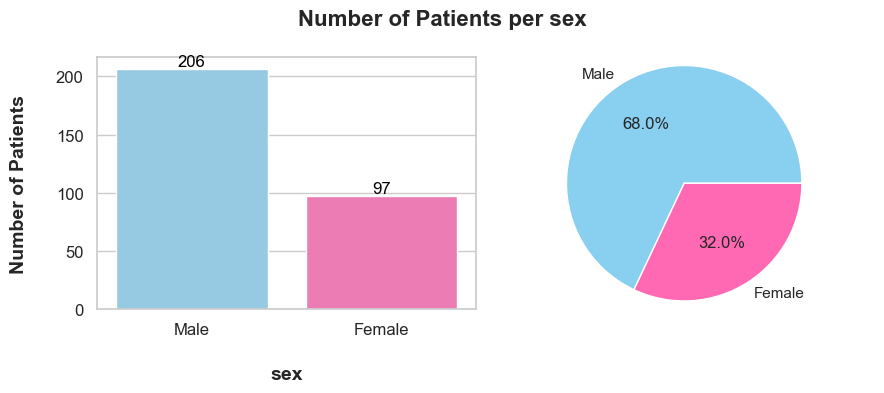

In [ ]:
plot_categorical_feature(gender_counts, figsize=(9,4))

<div style="padding:10px;
            color:#E55604;
            margin:10px;
            font-size:130%;
            display:fill;
            border-radius:5px;
            border-style: solid;
            border-color: #FF9B50;
            background-color:#000000;
            overflow:hidden;
            font-weight:400"><b>Visualizing the distribution of `cp` </b>
</div>

In [ ]:
category_counts = df["cp"].value_counts().reset_index()
category_counts

,cp,count
0,4.00,144
1,3.00,86
2,2.00,50
3,1.00,23


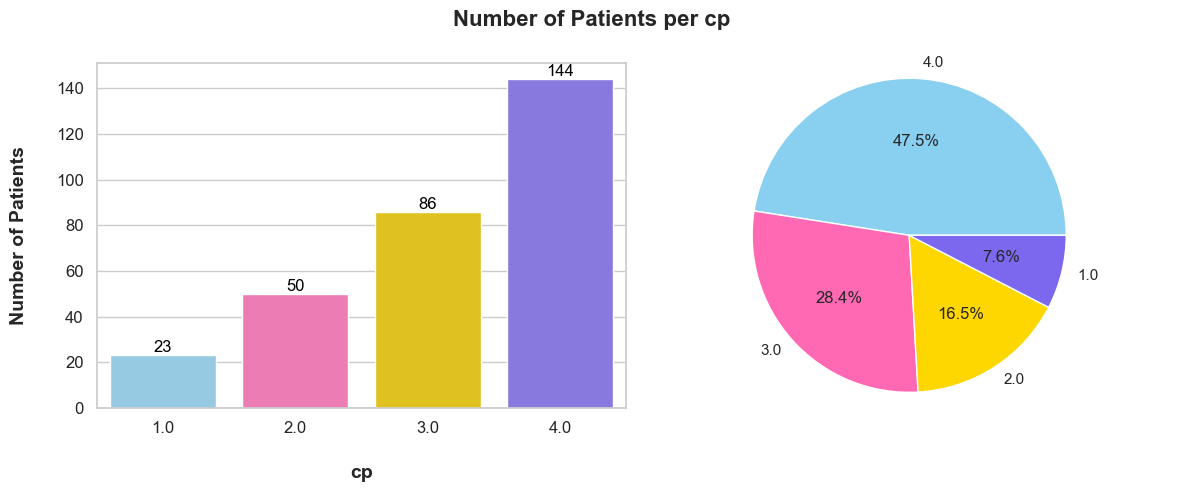

In [ ]:
plot_categorical_feature(category_counts)

<div style="padding:10px;
            color:#E55604;
            margin:10px;
            font-size:130%;
            display:fill;
            border-radius:5px;
            border-style: solid;
            border-color: #FF9B50;
            background-color:#000000;
            overflow:hidden;
            font-weight:400"><b>Visualizing the distribution of `thal` </b>
</div>

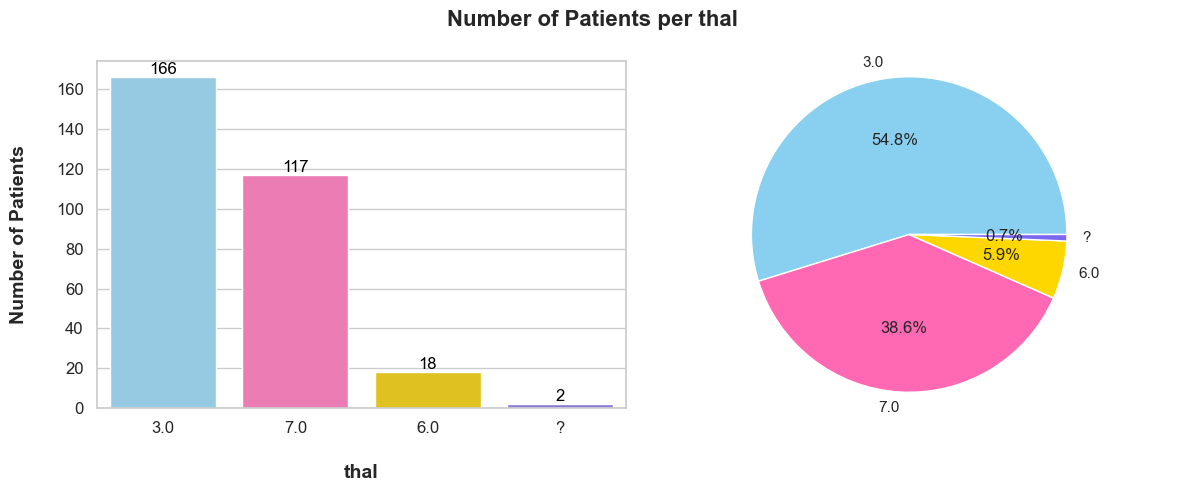

In [ ]:
category_counts = df["thal"].value_counts().reset_index()
plot_categorical_feature(category_counts)

# EDA FOR NUMERICAL FEATURES

In [ ]:
df[num_features].head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,target
0,63.00,Male,1.00,145.00,233.00,1.00,2.00,150.00,0.00,2.30,3.00,0
1,67.00,Male,4.00,160.00,286.00,0.00,2.00,108.00,1.00,1.50,2.00,2
2,67.00,Male,4.00,120.00,229.00,0.00,2.00,129.00,1.00,2.60,2.00,1
3,37.00,Male,3.00,130.00,250.00,0.00,0.00,187.00,0.00,3.50,3.00,0
4,41.00,Female,2.00,130.00,204.00,0.00,2.00,172.00,0.00,1.40,1.00,0


<div style="padding:10px;
            color:#E55604;
            margin:10px;
            font-size:130%;
            display:fill;
            border-radius:5px;
            border-style: solid;
            border-color: #FF9B50;
            background-color:#000000;
            overflow:hidden;
            font-weight:400"><b>Histogram of Age Distribution</b>
</div>

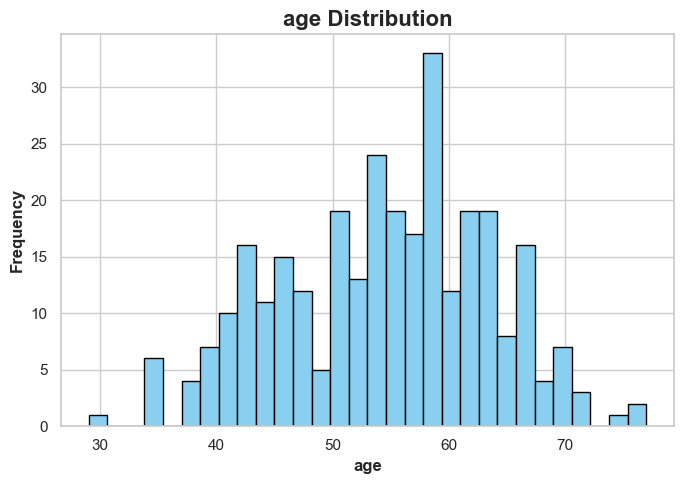

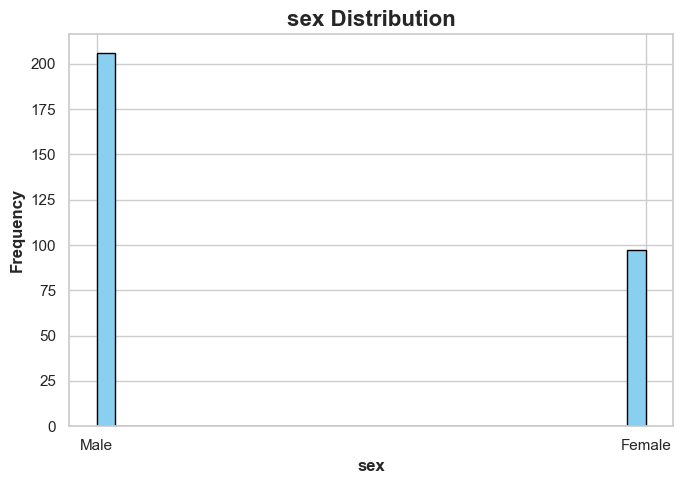

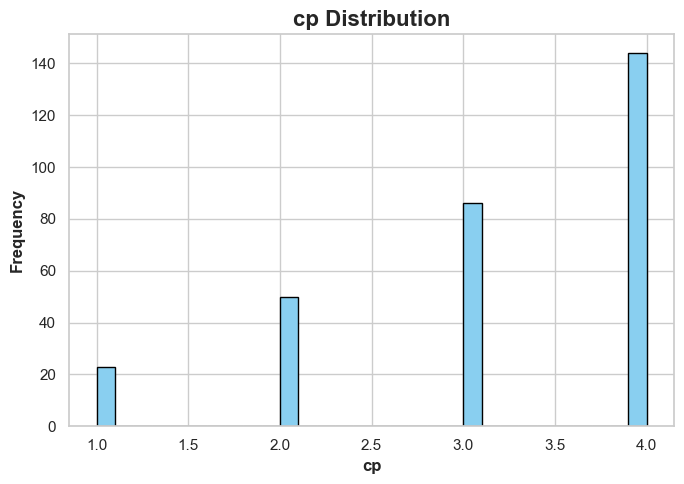

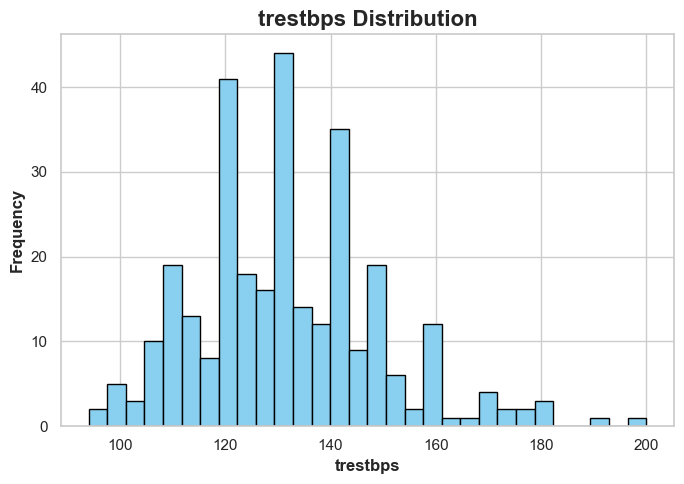

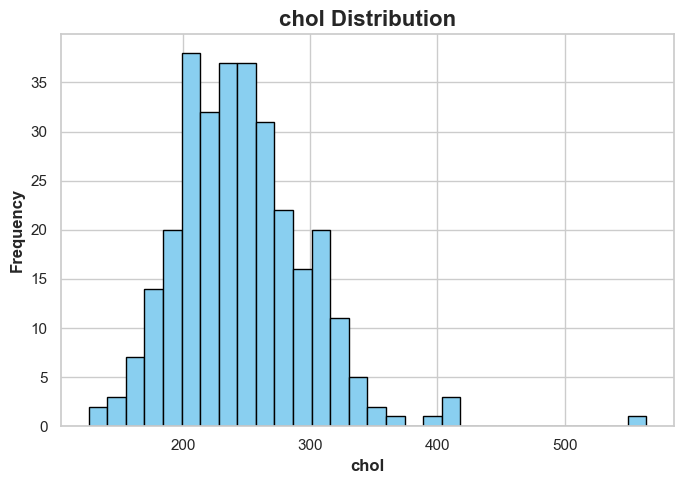

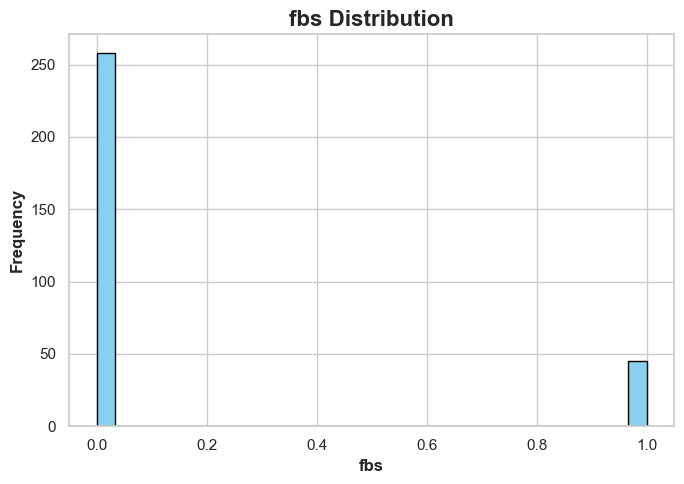

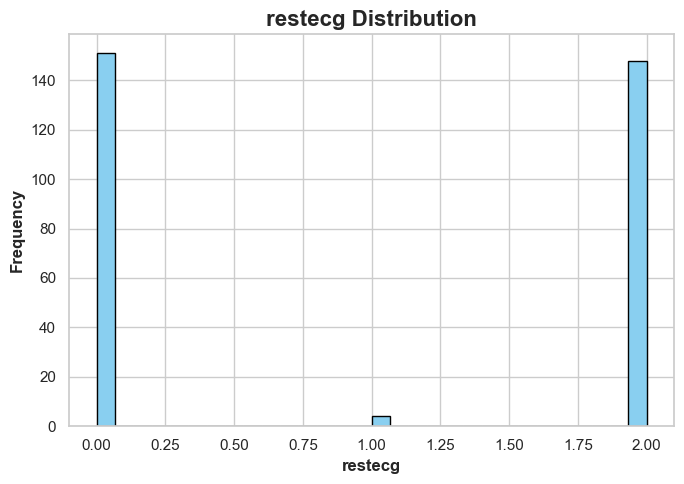

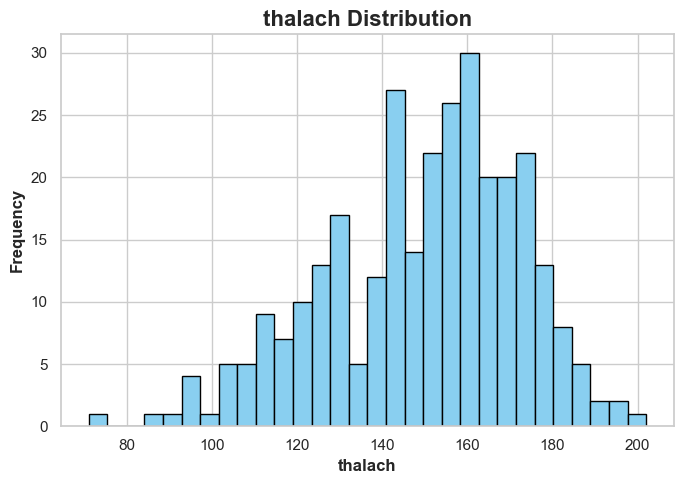

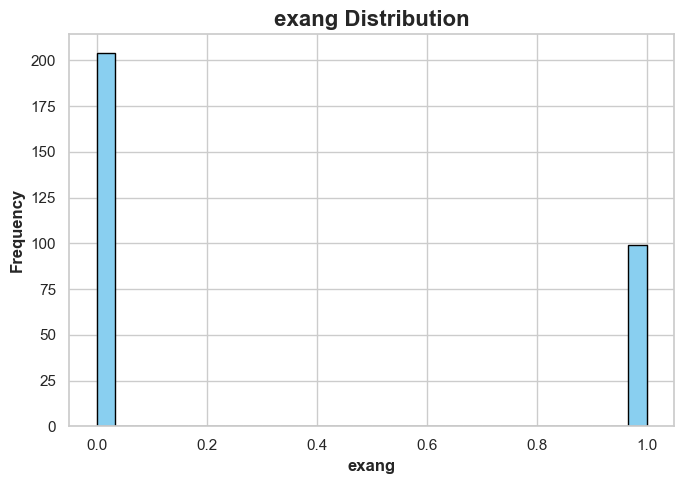

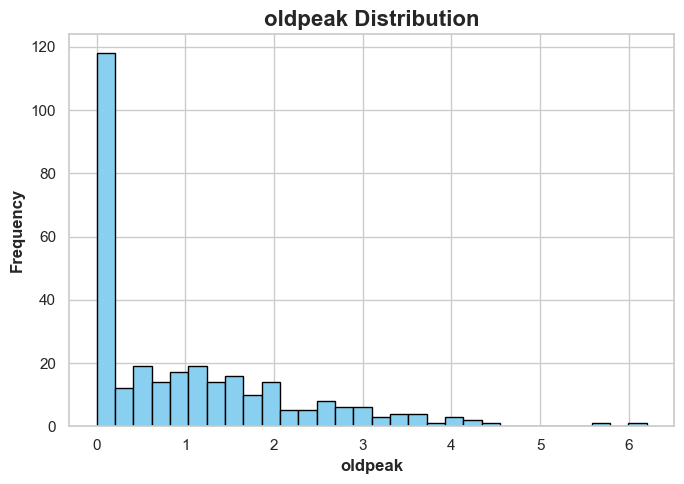

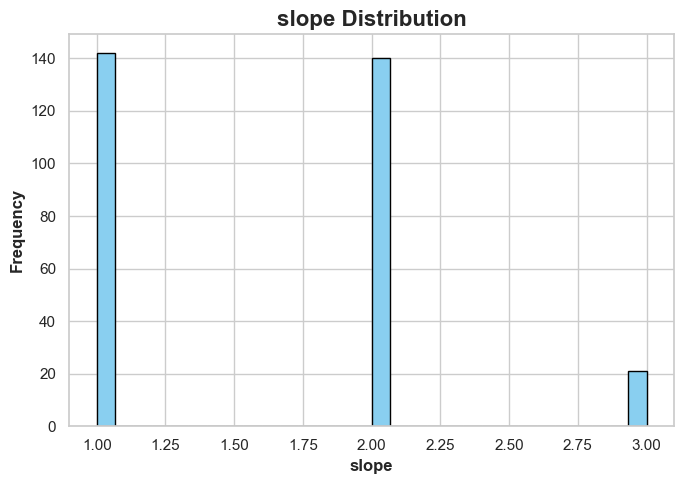

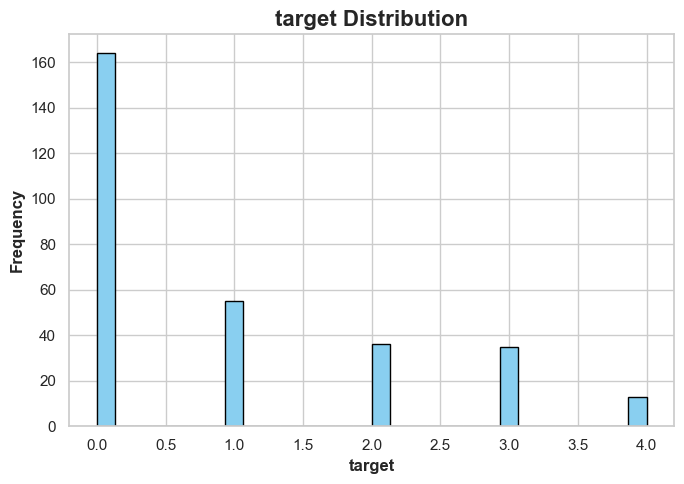

In [ ]:
for col in num_features[0:]:
    plt.figure(figsize = (7, 5))
    plt.hist(df[col], bins = 30, edgecolor = 'k')
    plt.title(f'{col} Distribution', weight = "bold", fontsize = 16)
    plt.xlabel(col, weight = "bold", fontsize = 12)
    plt.ylabel('Frequency', weight = "bold", fontsize = 12)

    plt.tight_layout()
    plt.show()

<div style="padding:10px;
            color:#E55604;
            margin:10px;
            font-size:130%;
            display:fill;
            border-radius:5px;
            border-style: solid;
            border-color: #FF9B50;
            background-color:#000000;
            overflow:hidden;
            font-weight:400"><b>What is the average age of patients in the dataset ?</b>
</div>

In [ ]:
average_age = df['age'].mean()
print(f"The average age of patients in the dataset is: {average_age:.2f} years")

The average age of patients in the dataset is: 54.44 years
